<a href="https://colab.research.google.com/github/LeoRoma8/ISSD_PH/blob/main/ROMANUTTI_LEONARDO_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


Al inspeccionar la pagina web me di cuenta de que el discurso estaba estructurado mediante bloques con las etiquetas "cite" Lo cual, utilice luego para poder extraer de la web, el texto de mi interes para ser usado en el TP, uniendo los parrafos en un solo cuerpo y tomando como separador de palabras los espacios " ".



In [1]:
import requests
from bs4 import BeautifulSoup

# URL del anexo con el discurso
url = "https://www.educ.ar/app/files/repositorio/html/91/44/d4df65dc-1f30-40eb-a26d-e492162856fa/14708/data/a41f8260-c854-11e0-83e4-e7f760fda940/anexo1.htm"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

response = requests.get(url, headers=headers)
response.encoding = response.apparent_encoding  # Mantiene las tildes y caracteres en español

soup = BeautifulSoup(response.text, "html.parser")

# Reemplazar posibles etiquetas <br> por saltos de línea reales dentro de cada cite
for br in soup.find_all("br"):
    br.replace_with("\n")

# Extraer todos los bloques contenidos en las etiquetas <cite>
elementos_cite = soup.find_all("cite")

# Limpiar y recopilar el texto de cada elemento
parrafos_discurso = [
    c.get_text(separator=" ", strip=True)
    for c in elementos_cite
    if c.get_text(strip=True)
]

# Unir los párrafos con doble salto de línea
texto_final = "\n\n".join(parrafos_discurso)

# Validaciones
print(f"Total de bloques <cite> encontrados: {len(elementos_cite)}")
print(f"Total de caracteres extraídos: {len(texto_final)}\n")

print("--- discurso extraído ---")
print(texto_final)
print("\n-------------------------------------------------")



Total de bloques <cite> encontrados: 10
Total de caracteres extraídos: 5301

--- discurso extraído ---
¡Trabajadores!

Hace casi dos años, desde estos mismos balcones, dije que tenía tres honras en mi vida: la de ser soldado, la de ser un patriota y la de ser el primer trabajador argentino. Hoy, a la tarde, el Poder Ejecutivo ha firmado mi solicitud de retiro del servicio activo del ejército. Con ello he renunciado voluntariamente, al más insigne honor a que puede aspirar un soldado: llevar las palmas y laureles de general de la nación. Ello lo he hecho porque quiero seguir siendo el Coronel Perón, y ponerme con este nombre al servicio integral del auténtico pueblo argentino.

Dejo el honroso uniforme que me entregó la patria, para vestir la casaca del civil y mezclarme con esa masa sufriente y sudorosa que elabora el trabajo y la grandeza de la patria. Por eso doy mi abrazo final a esa institución que es un puntal de la patria: el ejército. Y doy también el primer abrazo a esta masa, 

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [2]:
# ==============================================================================
# 1. Instalación y descarga de recursos de NLTK
# ==============================================================================

import re
import nltk
from collections import Counter
from nltk.corpus import stopwords

# Descargar la lista estándar de stopwords en español
nltk.download('stopwords')

# ==============================================================================
# 2. Tokenización y normalización del texto
# ==============================================================================
# Asumiendo que 'texto_final' contiene el texto extraído en el punto anterior
# Convertimos todo a minúsculas y extraemos solo palabras (alfanuméricas)
# Asegurandonos de incluir no solo las letras del alfabeto (a-z) si no tambien
# Caracteres propios del idioma castellano.

palabras_texto = re.findall(r'\b[a-záéíóúüñ]+\b', texto_final.lower())

# ==============================================================================
# 3. Filtrado y conteo de Stop Words presentes en el discurso
# ==============================================================================
stop_words_espanol = set(stopwords.words('spanish'))

# Identificar cuáles palabras del texto pertenecen a la lista de stop words
stop_words_encontradas = [palabra for palabra in palabras_texto if palabra in stop_words_espanol]

# Métricas
total_tokens = len(palabras_texto)
total_stopwords = len(stop_words_encontradas)
stopwords_unicas = set(stop_words_encontradas)
frecuencia_stopwords = Counter(stop_words_encontradas)

print(f"Total de palabras en el texto: {total_tokens}")
print(f"Total de stop words encontradas: {total_stopwords} ({round((total_stopwords / total_tokens) * 100, 2)}% del texto)")
print(f"Cantidad de stop words distintas: {len(stopwords_unicas)}\n")

# ==============================================================================
# 4. Mostrar las stop words más frecuentes en el discurso
# ==============================================================================
print("Top 20 stop words más recurrentes en el discurso:")
for palabra, count in frecuencia_stopwords.most_common(20):
    print(f"- '{palabra}': {count} apariciones")

Total de palabras en el texto: 907
Total de stop words encontradas: 480 (52.92% del texto)
Cantidad de stop words distintas: 81

Top 20 stop words más recurrentes en el discurso:
- 'que': 57 apariciones
- 'de': 40 apariciones
- 'la': 31 apariciones
- 'y': 29 apariciones
- 'a': 19 apariciones
- 'el': 16 apariciones
- 'por': 14 apariciones
- 'los': 14 apariciones
- 'en': 13 apariciones
- 'mi': 10 apariciones
- 'con': 10 apariciones
- 'este': 10 apariciones
- 'no': 10 apariciones
- 'un': 9 apariciones
- 'del': 9 apariciones
- 'lo': 9 apariciones
- 'para': 9 apariciones
- 'esta': 9 apariciones
- 'es': 8 apariciones
- 'como': 8 apariciones


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

In [3]:
!pip install wordcloud matplotlib nltk

Palabras totales originales: 907
Palabras luego de remover stop words y símbolos: 427


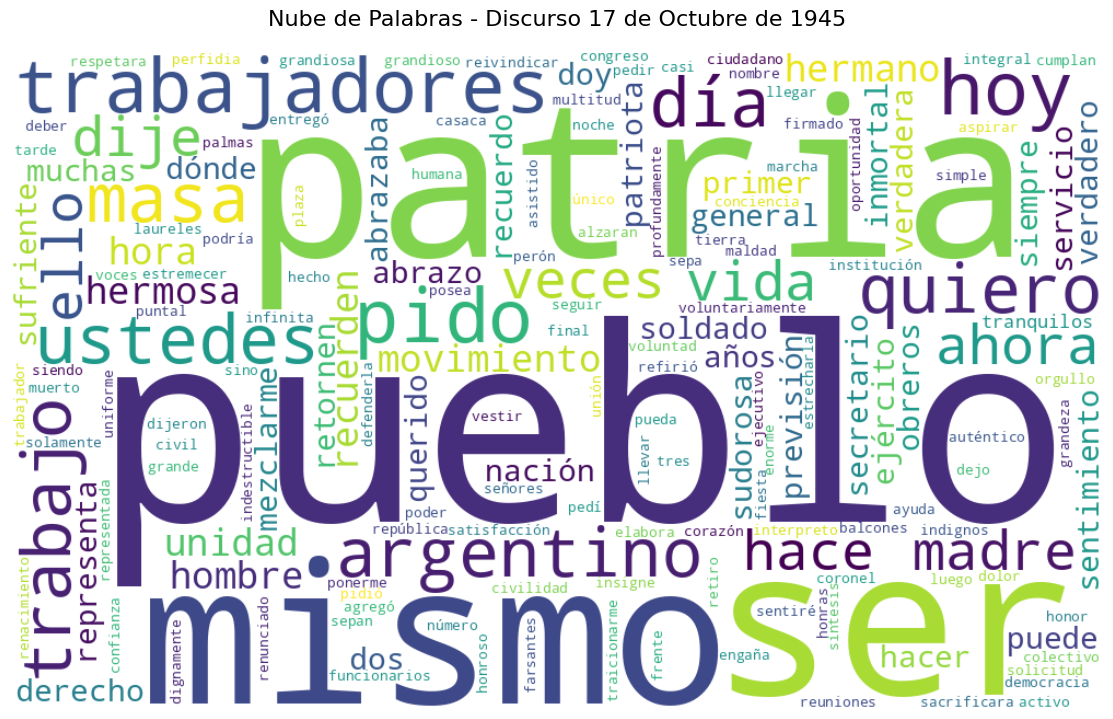

In [4]:
# ==============================================================================
# 1. Importación de bibliotecas
# ==============================================================================

import matplotlib.pyplot as plt
from wordcloud import WordCloud


# ==============================================================================
# Eliminación de stop words
# ==============================================================================

palabras_limpias = [palabra for palabra in palabras_texto if palabra not in stop_words_espanol]

# Unimos las palabras limpias en un solo string separado por espacios
texto_para_nube = " ".join(palabras_limpias)

print(f"Palabras totales originales: {len(palabras_texto)}")
print(f"Palabras luego de remover stop words y símbolos: {len(palabras_limpias)}")

# ==============================================================================
# 5. Creación y renderizado de la Nube de Palabras (WordCloud)
# ==============================================================================
# Configuramos la nube de palabras
nube_palabras = WordCloud(
    width=1000,
    height=600,
    background_color="white",       # Fondo blanco para mejor contraste
    colormap="viridis",             # Paleta de colores ('plasma', 'magma', 'inferno', etc.)
    collocations=False,             # Evita que junte palabras repetidas en pares
    min_font_size=10
).generate(texto_para_nube)

# Mostrar la nube con Matplotlib
plt.figure(figsize=(12, 7))
plt.imshow(nube_palabras, interpolation="bilinear")
plt.axis("off")                     # Ocultar los ejes cartesianos (x, y)
plt.title("Nube de Palabras - Discurso 17 de Octubre de 1945", fontsize=16, pad=20)
plt.tight_layout(pad=0)
plt.show()


### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [5]:
# ==============================================================================
# 1. Importación de librerías y recursos
# ==============================================================================
import pandas as pd
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('punkt_tab')  # Requerido en versiones recientes de NLTK
nltk.download('stopwords')

# ==============================================================================
# 2. Cargar el texto del discurso
# ==============================================================================

texto = texto_final  # Variable en memoria del paso anterior

# ==============================================================================
# 3. Descomposición en oraciones (Documentos)
# ==============================================================================
# sent_tokenize segmenta respetando puntos y signos de cierre (!?)
oraciones_crudas = sent_tokenize(texto, language='spanish')

print(f"Total de oraciones extraídas (filas de la matriz): {len(oraciones_crudas)}")

# ==============================================================================
# 4. Limpieza y preprocesamiento de cada oración
# ==============================================================================
def limpiar_oracion(oracion):
    # Pasar a minúsculas
    oracion = oracion.lower()
    # Conservar solo letras en español y espacios (remueve signos de puntuación, números, etc.)
    oracion = re.sub(r'[^a-záéíóúüñ\s]', ' ', oracion)
    # Colapsar espacios múltiples en uno solo
    oracion = re.sub(r'\s+', ' ', oracion).strip()
    return oracion

# Aplicar limpieza a cada oración y filtrar las que queden vacías
oraciones_limpias = [limpiar_oracion(o) for o in oraciones_crudas if len(limpiar_oracion(o)) > 0]

# ==============================================================================
# 5. Construcción de la Matriz Documento-Vocabulario (DTM)
# ==============================================================================
# Obtenemos la lista de stop words en español para excluir términos vacíos
stop_words_es = list(stopwords.words('spanish'))

# CountVectorizer tokeniza por palabras y arma la matriz de frecuencias
vectorizador = CountVectorizer(
    stop_words=stop_words_es,
    token_pattern=r'\b[a-záéíóúüñ]{2,}\b'  # Palabras de al menos 2 letras alfabéticas
)

# Ajustar y transformar las oraciones a matriz dispersa
dtm_sparse = vectorizador.fit_transform(oraciones_limpias)

# Vocabulario extraído (las columnas de la matriz)
vocabulario = vectorizador.get_feature_names_out()

# ==============================================================================
# 6. Representación en DataFrame de Pandas
# ==============================================================================
# Convertir a DataFrame donde:
# - Filas: Cada oración (Doc_1, Doc_2, ...)
# - Columnas: Cada término del vocabulario
df_dtm = pd.DataFrame(
    dtm_sparse.toarray(),
    index=[f"Oración_{i+1}" for i in range(len(oraciones_limpias))],
    columns=vocabulario)

display(df_dtm.head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total de oraciones extraídas (filas de la matriz): 40


,abandonar,abrazaba,abrazo,activo,acto,agradecimiento,agregó,ahora,alzaran,ambición,...,vieja,vienen,vivido,voces,voluntad,voluntariamente,último,únanse,única,único
Oración_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Oración_5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_7,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_8,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Oración_10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

In [6]:
print(f"La longitud del vocabulario es:", len(vocabulario))

La longitud del vocabulario es: 304



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [7]:
# ==============================================================================
# 1. Importación y construcción con TfidfVectorizer
# ==============================================================================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,
    token_pattern=r'\b[a-záéíóúüñ]{2,}\b'
)

# Ajustar y transformar
tfidf_sparse = tfidf_vectorizer.fit_transform(oraciones_limpias)
vocabulario_tfidf = tfidf_vectorizer.get_feature_names_out()

# ==============================================================================
# 2. Representación en DataFrame
# ==============================================================================
df_tfidf = pd.DataFrame(
    tfidf_sparse.toarray(),
    index=[f"Oración_{i+1}" for i in range(len(oraciones_limpias))],
    columns=vocabulario_tfidf
)

print(f"Dimensiones de la matriz TF-IDF: {df_tfidf.shape[0]} oraciones x {df_tfidf.shape[1]} términos\n")

# Muestra de las primeras 5 oraciones
print("--- Muestra de la matriz TF-IDF (valores normalizados 0 a 1) ---")
display(df_tfidf.iloc[:10, :8].round(3))

Dimensiones de la matriz TF-IDF: 40 oraciones x 304 términos

--- Muestra de la matriz TF-IDF (valores normalizados 0 a 1) ---


,abandonar,abrazaba,abrazo,activo,acto,agradecimiento,agregó,ahora
Oración_1,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0
Oración_2,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0
Oración_3,0.0,0.0,0.000,0.332,0.0,0.0,0.0,0.0
Oración_4,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0
Oración_5,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0
Oración_6,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0
Oración_7,0.0,0.0,0.372,0.000,0.0,0.0,0.0,0.0
Oración_8,0.0,0.0,0.267,0.000,0.0,0.0,0.0,0.0
Oración_9,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0
Oración_10,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.0


In [8]:
# ==============================================================================
# 3. Identificar el término más relevante (mayor TF-IDF) por oración
# ==============================================================================
palabras_clave_por_oracion = []

for idx, fila in df_tfidf.iterrows():
    if fila.max() > 0:
        top_termino = fila.idxmax()
        score = fila.max()
        palabras_clave_por_oracion.append((idx, top_termino, round(score, 3)))


df_top_words = pd.DataFrame(palabras_clave_por_oracion, columns=["Oración", "Término Clave", "Score TF-IDF"])
print("Palabra distintiva por oración:")
display(df_top_words.head(10))

Palabra distintiva por oración:


,Oración,Término Clave,Score TF-IDF
0,Oración_1,trabajadores,1.000
1,Oración_2,ser,0.527
2,Oración_3,activo,0.332
3,Oración_4,aspirar,0.290
4,Oración_5,auténtico,0.290
5,Oración_6,patria,0.346
6,Oración_7,final,0.413
7,Oración_8,civilidad,0.297
8,Oración_9,pueblo,1.000
9,Oración_10,dolor,0.422


Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones:

La matriz resultante esta constituida por 40 oraciones(documentos) y 304 terminos resultantes del reprocesamiento del texto original luego de exlcuir las stop words y los caracteres como '.' ',' etc.

Luego de realizada esta normalizacion y limpieza se armo una matriz para identificar el termino mas relevante por oracion y asi poder deducir las intenciones y
 el desarrollo del discurso analizado.

# Conclusiones
La consigan en general me resulto interesanta.
El webscrapping y posterior analisis del discurso elegido arrojo los resultados esperados. Era un discruso que ya conocia, pero no estaba familiarizado con la tecnica del webscrapping y toda la limpieza, depuracion y consideraciones que deben tenerse en cuenta para obtener un resultado limpio que luego pueda ser utilizado para construir clusters, analizar las distancias entre los terminos y demas cosas que no realice en este colab pero que estuve investigando.

Con el fin de responder a las consignas solicitadas, parte del codigo fue realizado con la ayuda de "Gemini". Pero el analisis, lectura y exploracion de la url elegida fueron realizados con criterio propio.
